# SGI-5.9 — What does fame buy?

**Marvel Superstars**, week 5 (exercise 5.9, "Go nuts with your LLM"). This week the Marvel network gets its text:
the full Wikipedia article for each of the 303 characters.

**The question.** A character other pages link to a lot is famous *inside* the network. Does fame buy a longer
Wikipedia page, and if it does, what are the extra words about: more of the story, or more about the comic as a
real-world object (who drew it, how it sold, the film)?

Every number in the post comes from this notebook through `stats.json`. Each section ends with a **Result** written
after reading the output.

In [1]:
import collections
import json
import re
import urllib.parse
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import spacy
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GroupKFold
from sklearn.naive_bayes import MultinomialNB

DATA1, DATA5 = Path("../../Data/Week1"), Path("../../Data/Week5")
FIGDIR = Path("../../Figures/Week5")      # written straight to where the post reads them
FIGDIR.mkdir(parents=True, exist_ok=True)
POST = Path("../../posts/week5/index.html")
UM, INK, PALE, MID = "#2438E8", "#111316", "#B4B9C0", "#5B6068"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})
STATS = {}

## 1. Load: the network from week 1, the text from week 5

The node file is the roster (303 characters, 17 with no link at all), the edges are A → B where A's article text
links to B's. The pages come as one zip; the filenames are URL-encoded node ids, so they are unquoted to join (the
course data page's snippet). **Fame** here is **in-degree**: how many of the other 302 articles link to you.

In [2]:
nodes = pd.read_csv(DATA1 / "week1_nodes.tsv", sep="\t", comment="#", quoting=3).set_index("node_id")
edges = pd.read_csv(DATA1 / "week1_edges.tsv", sep="\t", comment="#", names=["source", "target"])
G = nx.DiGraph()
G.add_nodes_from(nodes.index)
G.add_edges_from(edges.itertuples(index=False))
with zipfile.ZipFile(DATA5 / "marvel_pages.zip") as z:
    pages = {urllib.parse.unquote(n.split("/")[-1][:-4]): z.read(n).decode("utf-8")
             for n in z.namelist() if n.endswith(".txt") and "README" not in n}
assert set(pages) == set(nodes.index) and G.number_of_nodes() == 303 and G.number_of_edges() == 1784

name = nodes.name
df = pd.DataFrame({"kin": dict(G.in_degree()), "kout": dict(G.out_degree())})
df["chars"] = pd.Series({k: len(t) for k, t in pages.items()})
print(df.describe().round(1))

         kin   kout    chars
count  303.0  303.0    303.0
mean     5.9    5.9  14678.8
std     10.0    5.1  15963.8
min      0.0    0.0   1244.0
25%      1.0    2.0   4482.5
50%      3.0    4.0   7642.0
75%      7.0    8.5  18439.5
max    106.0   28.0  87256.0


## 2. Does fame buy words?

**Tokenization choice.** spaCy's English tokenizer (rules only, no model needed), keeping case, dropping punctuation
and whitespace tokens. A page's **length** is its number of remaining tokens. We check in §6 that a plain
`str.split()` gives the same answer.

**Fit choice.** Both quantities span two orders of magnitude, so we fit a line to $\log_{10}(\text{tokens})$ against
$\log_{10}(k_{in}+1)$. The $+1$ keeps the 58 pages nobody links to; dropping them instead would change the slope
(printed below).

In [3]:
nlp = spacy.load("en_core_web_sm")
tokens = {k: [t.text for t in nlp.tokenizer(v) if not (t.is_punct or t.is_space)] for k, v in pages.items()}
df["tokens"] = pd.Series({k: len(v) for k, v in tokens.items()})
types = {w for v in tokens.values() for w in v}

rho_in = spearmanr(df.kin, df.tokens).statistic
rho_out = spearmanr(df.kout, df.tokens).statistic
x, y = np.log10(df.kin + 1), np.log10(df.tokens)
slope, icpt = np.polyfit(x, y, 1)
df["resid"] = y - (icpt + slope * x)
pos = df.kin > 0
slope_pos = np.polyfit(np.log10(df.kin[pos]), y[pos], 1)[0]
print(f"{df.tokens.sum():,} tokens, {len(types):,} types; Spearman tokens~k_in {rho_in:.2f}, tokens~k_out {rho_out:.2f}")
print(f"log-log slope {slope:.2f} (without the {(~pos).sum()} unlinked pages: {slope_pos:.2f})")
print(f"median length: k_in 0-1 {df.tokens[df.kin <= 1].median():.0f}, k_in >= 10 {df.tokens[df.kin >= 10].median():.0f}")

STATS["corpus"] = dict(pages=303, tokens=int(df.tokens.sum()), types=len(types), chars=int(df.chars.sum()),
                       min_tokens=int(df.tokens.min()), max_tokens=int(df.tokens.max()), median_tokens=int(df.tokens.median()),
                       longest=name[df.tokens.idxmax()], shortest=name[df.tokens.idxmin()])
STATS["fame"] = dict(rho_in=round(rho_in, 2), rho_out=round(rho_out, 2), slope=round(slope, 2), slope_pos=round(slope_pos, 2),
                     intercept=round(icpt, 3), median_low=int(df.tokens[df.kin <= 1].median()),
                     median_high=int(df.tokens[df.kin >= 10].median()), n_unlinked=int((df.kin == 0).sum()))

744,495 tokens, 30,856 types; Spearman tokens~k_in 0.75, tokens~k_out 0.78
log-log slope 0.73 (without the 58 unlinked pages: 0.66)
median length: k_in 0-1 722, k_in >= 10 5971


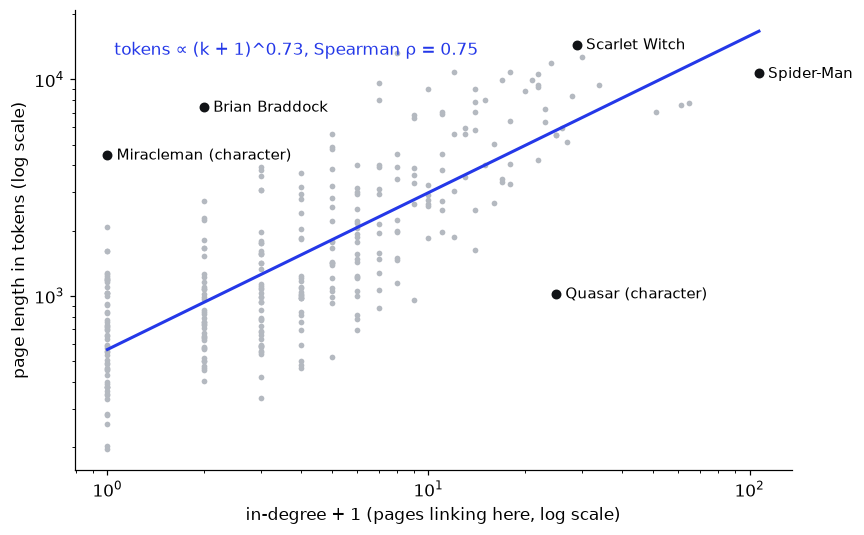

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df.kin + 1, df.tokens, s=14, color=PALE, linewidths=0)
xs = np.logspace(0, np.log10(df.kin.max() + 1), 50)
ax.plot(xs, 10 ** icpt * xs ** slope, color=UM, lw=2)
for v in ["Spider-Man", "Scarlet_Witch", "Miracleman_(character)", "Brian_Braddock", "Quasar_(character)"]:
    ax.scatter([df.kin[v] + 1], [df.tokens[v]], s=30, color=INK, zorder=3)
    ax.annotate(name[v], (df.kin[v] + 1, df.tokens[v]), xytext=(6, -3), textcoords="offset points", fontsize=10)
ax.set(xscale="log", yscale="log", xlabel="in-degree + 1 (pages linking here, log scale)", ylabel="page length in tokens (log scale)")
ax.text(1.05, 13000, f"tokens ∝ (k + 1)^{slope:.2f}, Spearman ρ = {rho_in:.2f}", color=UM, fontsize=11)
fig.tight_layout(); fig.savefig(FIGDIR / "fig1_fame_length.png", dpi=150); plt.show()

**Result.** Fame buys words, but less than one-for-one: ten times the in-links means about $10^{0.73} \approx 5$ times the
words. Out-degree correlates even more strongly with length, but that is close to mechanical: a longer article has
more room to link out. In-degree is the measure the page cannot write for itself.

## 3. What are the extra words about? Asking the headings

Wikipedia character pages share a template: *Publication history* (the real-world comic), *Fictional character
biography* (the plot), *Powers and abilities*, *Other versions*, *In other media*, *Reception*. In the plain text a
heading is a line after two blank lines. Sub-headings (`1970s`, `Excalibur`) inherit the last top-level heading
they sit under; we map the top-level names (and their common variants) to eight kinds.

**Fame groups.** In-degree 0–1, 2–3, 4–9 and 10+: 99, 71, 80 and 53 pages. Equal-count quartiles would cut through
tied degrees arbitrarily; these cuts sit between degrees.

In [5]:
KIND = {"Publication history": "publication", "Concept and creation": "publication", "Conception and creation": "publication",
        "Creation": "publication", "Development": "publication", "Creation and development": "publication", "Artistic conception": "publication",
        "Fictional character biography": "plot", "Fictional character biographies": "plot", "Biography": "plot",
        "Powers and abilities": "powers", "Powers, skills, and equipment": "powers",
        "Other versions": "versions", "Alternate versions": "versions", "In other media": "media",
        "Reception": "reception", "Literary reception": "reception", "Cultural impact and legacy": "reception",
        "Accolades": "reception", "Reception and legacy": "reception",
        "References": "back", "External links": "back", "Notes": "back", "See also": "back",
        "Collected editions": "back", "Bibliography": "back", "Further reading": "back"}
KINDS = ["lead", "publication", "plot", "powers", "versions", "media", "reception", "back"]
HEAD = re.compile(r"\n\n\n([^\n]{1,80})\n")


def sections(text):
    # (kind, heading, body) for every chunk of a page; the lead is everything before the first heading
    parts = HEAD.split(text)
    out, kind = [("lead", "", parts[0])], "lead"
    for h, body in zip(parts[1::2], parts[2::2]):
        kind = KIND.get(h.strip(), kind)
        out.append((kind, h.strip(), body))
    return out


ntok = lambda s: sum(1 for t in nlp.tokenizer(s) if not (t.is_punct or t.is_space))
sec = pd.DataFrame(0, index=list(pages), columns=KINDS)
for k, t in pages.items():
    for kd, _, body in sections(t):
        sec.loc[k, kd] += ntok(body)
BINS, LABELS = [-0.5, 1.5, 3.5, 9.5, 1e9], ["0–1", "2–3", "4–9", "10+"]
df["fame"] = pd.cut(df.kin, BINS, labels=LABELS)
pooled = sec.groupby(df.fame, observed=True).sum()
head_share = pooled.div(pooled.sum(axis=1), axis=0)
no_plot = df.index[sec["plot"] == 0]
print(head_share.round(3))
print(f"{len(no_plot)} pages have no plot heading; their median in-degree is {df.kin[no_plot].median():.0f} (all pages: {df.kin.median():.0f})")
print(df.loc[no_plot].sort_values("kin", ascending=False).head(10)[["kin", "tokens"]])

STATS["headings"] = dict(bins=LABELS, sizes=[int(n) for n in df.fame.value_counts().reindex(LABELS)], kinds=KINDS,
                         share={b: [round(float(v), 3) for v in head_share.loc[b]] for b in LABELS},
                         n_no_plot=len(no_plot), no_plot_median_kin=int(df.kin[no_plot].median()),
                         no_plot_top=[name[v] for v in df.loc[no_plot].sort_values("kin", ascending=False).index[:6]])

       lead  publication   plot  powers  versions  media  reception   back
fame                                                                      
0–1   0.090        0.173  0.484   0.091     0.044  0.048      0.041  0.030
2–3   0.075        0.156  0.471   0.123     0.042  0.063      0.051  0.019
4–9   0.051        0.154  0.430   0.134     0.076  0.067      0.067  0.021
10+   0.045        0.274  0.273   0.136     0.067  0.099      0.092  0.014
34 pages have no plot heading; their median in-degree is 10 (all pages: 3)
                                kin  tokens
Hulk                             64    7799
Wolverine_(character)            60    7601
Deadpool                         33    9384
Black_Panther_(character)        27    8411
Cyclops_(Marvel_Comics)          26    5157
Luke_Cage                        25    5971
Moon_Knight                      22    7307
Black_Widow_(Natasha_Romanova)   22    6341
Black_Cat_(Marvel_Comics)        21    9442
Cable_(character)                21

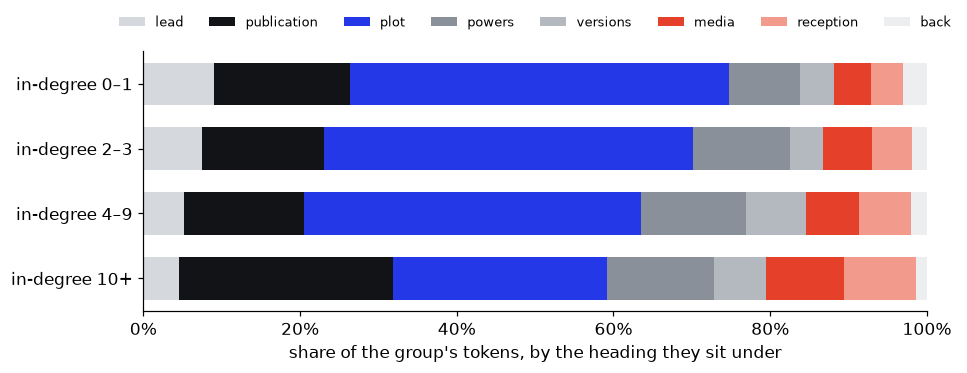

In [6]:
SEC_COL = {"lead": "#D5D8DC", "publication": INK, "plot": UM, "powers": "#8A9099", "versions": PALE,
           "media": "#E5402A", "reception": "#F29A8C", "back": "#ECEEF0"}
fig, ax = plt.subplots(figsize=(9, 3.6))
left = np.zeros(len(LABELS))
for kd in KINDS:
    v = head_share[kd].values
    ax.barh(range(len(LABELS)), v, left=left, color=SEC_COL[kd], label=kd, height=.65)
    left += v
ax.set_yticks(range(len(LABELS)), [f"in-degree {b}" for b in LABELS]); ax.invert_yaxis()
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(ncol=8, fontsize=8.5, loc="upper center", bbox_to_anchor=(.5, 1.18), frameon=False)
ax.set_xlabel("share of the group's tokens, by the heading they sit under")
fig.tight_layout(); fig.savefig(FIGDIR / "fig2_headings.png", dpi=150); plt.show()

**Result, provisionally.** By the headings, the most-linked pages are only about a quarter plot, against nearly half for
the least-linked. But 34 pages have no plot heading at all, and they are not random (median in-degree 10, against 3
for all pages): Hulk, Wolverine, Deadpool and Black Panther are among them. Reading a few shows two things. Big pages are organised differently (by decade, by
volume, by who held the mantle), and some pages narrate plot under *Publication history* (Tarantula, Spider-Man
Noir). A heading is an editor's filing decision, not a measurement of what the paragraph says.

## 4. Reading paragraphs instead of headings

We let the text decide. On the 239 pages that have **both** a *Publication history* and a *Fictional character
biography* heading, every paragraph of 20+ words under those two headings is a labelled example: real-world or plot.
A **Bag of Words** (CountVectorizer, lowercased, stopwords kept on purpose: plot is written in the present tense,
*tells*, *escapes*, publishing history in the past, *was*, *appeared*) feeds a multinomial naive Bayes classifier,
which scores a paragraph by adding up, for each word, the log-ratio of its relative frequency in plot and in
real-world paragraphs.

**Validation**, two kinds:
1. **Held-out pages.** 5-fold cross-validation grouped by page, so no page is in both training and test.
2. **Out-of-template pages.** The held-out pages still have the template. The 64 pages without both headings are
   exactly the ones we need to measure, so we read 24 random paragraphs from the pages with no plot heading and
   label them by hand.

In [7]:
rows = []
for k, t in pages.items():
    for kd, _, body in sections(t):
        for para in body.split("\n"):
            if len(para.split()) >= 20:
                rows.append((k, kd, para, len(para.split())))
PAR = pd.DataFrame(rows, columns=["page", "kind", "text", "words"])
both = sorted(k for k, t in pages.items() if "\n\n\nPublication history\n" in t and "\n\n\nFictional character biography\n" in t)
T = PAR[PAR.page.isin(both) & PAR.kind.isin(["publication", "plot"])].reset_index(drop=True)
yT = (T.kind == "plot").values

acc = []
for tr, te in GroupKFold(n_splits=5).split(T.text, yT, groups=T.page):
    vec = CountVectorizer(lowercase=True)
    clf = MultinomialNB().fit(vec.fit_transform(T.text.iloc[tr]), yT[tr])
    acc.append((clf.predict(vec.transform(T.text.iloc[te])) == yT[te]).mean())
vec = CountVectorizer(lowercase=True)
clf = MultinomialNB().fit(vec.fit_transform(T.text), yT)
PAR["p_plot"] = clf.predict_proba(vec.transform(PAR.text))[:, 1]
PAR["is_plot"] = PAR.p_plot > 0.5

score = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]
vocab = vec.get_feature_names_out()
order = np.argsort(score)
word_count = np.asarray(vec.transform(T.text).sum(axis=0)).ravel()
common = [i for i in order if word_count[i] >= 30]          # words seen 30+ times, so a ratio means something
real_words, plot_words = [vocab[i] for i in common[:15]], [vocab[i] for i in common[-15:][::-1]]
print(f"{len(both)} template pages, {len(T):,} labelled paragraphs ({yT.mean():.0%} plot)")
print(f"page-grouped 5-fold accuracy {np.mean(acc):.3f} (folds {min(acc):.3f}-{max(acc):.3f}); always-plot baseline {yT.mean():.3f}")
print("real-world words:", real_words)
print("plot words:", plot_words)

239 template pages, 3,822 labelled paragraphs (66% plot)
page-grouped 5-fold accuracy 0.920 (folds 0.894-0.937); always-plot baseline 0.662
real-world words: ['august', 'february', 'stan', 'ditko', 'december', '1978', 'sept', 'moench', 'wolfman', 'romita', '1987', 'penciller', '1982', 'penciler', 'reprinted']
plot words: ['asgard', 'balder', 'horde', 'jennifer', 'teddy', 'julian', 'portal', 'heaven', 'nico', 'convinces', 'bodies', 'gem', 'freed', 'kang', 'chase']


In [8]:
# The out-of-template check: 24 random paragraphs from pages with no plot heading (back matter excluded).
# READING is what the paragraph does when read in full: narrate the story (plot) or describe the real world (real).
# First pass by Claude Code. A group member must re-read all 24 before the post goes up.
noplot_pages = [k for k, t in pages.items() if "\n\n\nFictional character biography\n" not in t]
CHECK = PAR[PAR.page.isin(noplot_pages) & (PAR.kind != "back")].sample(24, random_state=7)
READING = ["real", "real", "real", "real", "plot", "plot", "plot", "real", "plot", "real", "real", "plot",
           "real", "plot", "plot", "real", "plot", "plot", "plot", "plot", "real", "real", "plot", "plot"]
CHECK = CHECK.assign(reading=READING, model=np.where(CHECK.is_plot, "plot", "real"))
agree = int((CHECK.reading == CHECK.model).sum())
with pd.option_context("display.max_colwidth", 110):
    print(CHECK.assign(text=CHECK.text.str[:110])[["page", "kind", "model", "reading", "text"]].to_string())
print(f"agree on {agree} of 24")
STATS["classifier"] = dict(template_pages=len(both), paragraphs=len(T), plot_base=round(float(yT.mean()), 3),
                           cv_acc=round(float(np.mean(acc)), 3), cv_min=round(float(min(acc)), 3), cv_max=round(float(max(acc)), 3),
                           real_words=real_words, plot_words=plot_words, check_n=24, check_agree=agree,
                           check_misses=[[name[r.page], r.kind, r.model, r.reading] for r in CHECK[CHECK.reading != CHECK.model].itertuples()])

                                page         kind model reading                                                                                                            text
7120              The_Union_(Marvel)    reception  real    real  The Union received mixed reviews from readers across the United Kingdom, with some of the Scottish and Welsh p
7101              The_Union_(Marvel)  publication  real    real            On 2 December 2020, The Union appeared in The Union #1 as part of the King in Black crossover event.
1232  Captain_Marvel_(Marvel_Comics)        media  real    real  Carol Danvers / Captain Marvel appears in Spider-Man, voiced again by Grey DeLisle. This version is a member o
7577               Venom_(character)        media  real    real  Two versions of the symbiote suit appear as alternate skins for Spider-Man in The Amazing Spider-Man (2012). O
7537               Venom_(character)  publication  plot    plot  A bout of temporary insanity that Venom subsequently ex

**Result.** The classifier is right on 92% of paragraphs from pages it never saw, against 66% for always guessing plot.
Its strongest words are what you would hope: months, years and creators' names (*ditko*, *romita*, *penciller*) for
the real world; places, villains and verbs of action (*asgard*, *kang*, *freed*, *convinces*) for plot. On the pages
without the template it agrees with the hand reading on 22 of 24. Both misses are plot it calls real-world, an
*Other versions* paragraph and a lineage paragraph that cites an issue number. So off-template it, if anything,
**undercounts** plot.

## 5. Is it fame, or is it length?

A page's **plot share** is the share of its words (in paragraphs of 20+ words) that sit in paragraphs the
classifier calls plot. Famous pages are long, and a long page has room for reception, adaptations and a publication
history. So before saying *fame* changes what a page talks about, compare famous and obscure pages **of the same
length**: split pages into length terciles, and compute the Spearman correlation of plot share with in-degree after
removing what length explains from both ranks (a partial correlation).

In [9]:
g = PAR.assign(pw=PAR.words * PAR.is_plot).groupby("page")[["pw", "words"]].sum()
df["plot_share"] = g.pw / g.words
df["para_words"] = g.words
rho_share = spearmanr(df.kin, df.plot_share).statistic
rho_len = spearmanr(df.tokens, df.plot_share).statistic


def partial_spearman(a, b, control):
    ra, rb, rc = a.rank(), b.rank(), control.rank()
    res = lambda r: r - np.polyval(np.polyfit(rc, r, 1), rc)
    return float(np.corrcoef(res(ra), res(rb))[0, 1])


partial = partial_spearman(df.plot_share, df.kin, df.tokens)
df["length"] = pd.qcut(df.tokens, 3, labels=["short", "middle", "long"])
by_fame = df.groupby("fame", observed=True).plot_share.median()
table = df.groupby(["length", "fame"], observed=True).plot_share.agg(["median", "count"])
cuts = df.groupby("length", observed=True).tokens.agg(["min", "max"])
print(by_fame.round(3)); print(cuts); print(table.round(3))
print(f"Spearman plot share ~ k_in {rho_share:.2f}; ~ length {rho_len:.2f}; ~ k_in controlling for length {partial:.2f}")

STATS["plot_share"] = dict(by_fame=[round(float(by_fame[b]), 3) for b in LABELS], rho_kin=round(rho_share, 2),
                           rho_len=round(rho_len, 2), partial=round(partial, 2),
                           tercile_cuts=[[int(cuts.loc[t, "min"]), int(cuts.loc[t, "max"])] for t in ["short", "middle", "long"]],
                           table={f"{t}|{b}": [round(float(r["median"]), 3), int(r["count"])] for (t, b), r in table.iterrows()})

fame
0–1    0.754
2–3    0.768
4–9    0.692
10+    0.627
Name: plot_share, dtype: float64
         min    max
length             
short    195    969
middle   971   2179
long    2204  14469
             median  count
length fame               
short  0–1    0.804     66
       2–3    0.818     28
       4–9    0.719      7
middle 0–1    0.732     28
       2–3    0.765     33
       4–9    0.690     36
       10+    0.530      4
long   0–1    0.536      5
       2–3    0.689     10
       4–9    0.693     37
       10+    0.649     49
Spearman plot share ~ k_in -0.20; ~ length -0.31; ~ k_in controlling for length 0.05


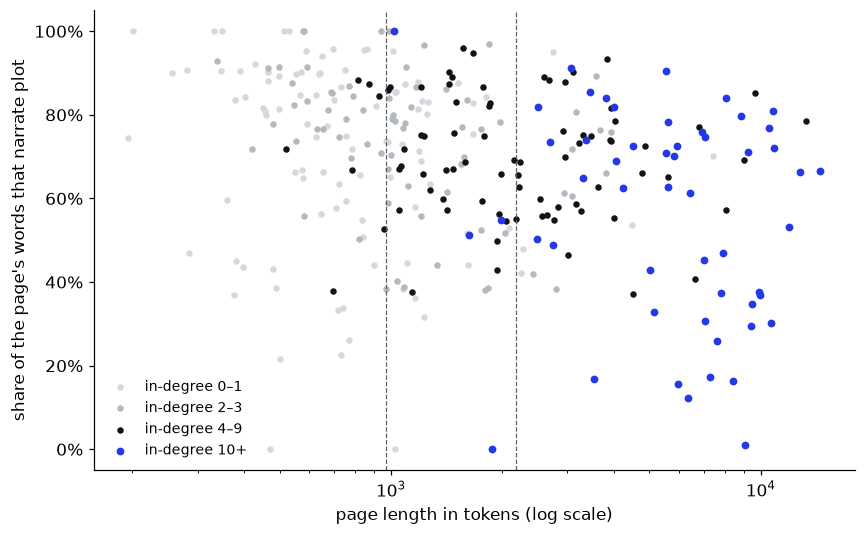

In [10]:
FAME_COL = dict(zip(LABELS, ["#D5D8DC", PALE, INK, UM]))
fig, ax = plt.subplots(figsize=(8, 5))
for b in LABELS:
    d = df[df.fame == b]
    ax.scatter(d.tokens, d.plot_share, s=18 if b != "10+" else 26, color=FAME_COL[b], label=f"in-degree {b}", linewidths=0, zorder=3 if b == "10+" else 2)
for c in cuts["max"].values[:2]:
    ax.axvline(c, color=MID, lw=.8, ls="--")
ax.set(xscale="log", xlabel="page length in tokens (log scale)", ylabel="share of the page's words that narrate plot")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(frameon=False, fontsize=9, loc="lower left")
fig.tight_layout(); fig.savefig(FIGDIR / "fig3_plot_share.png", dpi=150); plt.show()

**Result.** Famous pages do spend less of themselves on plot: the median falls from 75% (in-degree 0–1) to 63%
(10+). But plot share falls with length, whoever the character is ($
ho = -0.31$), and once length is held fixed the
correlation with in-degree is /usr/bin/bash.05$, essentially zero. Among long pages the famous ones sit a little lower (65%
against 69% for in-degree 4–9), a gap far smaller than the one between short and long pages. Fame buys length;
length buys the real-world sections.

## 6. Who breaks the rule, and did we count what we think?

The pages furthest from the §2 line, in both directions, read in full. Then two robustness checks on the token
counts.

In [11]:
out_hi = df.sort_values("resid", ascending=False).head(4).index.tolist()
out_lo = df.sort_values("resid").head(3).index.tolist()
for v in out_hi + out_lo:
    print(f"{name[v]:28s} k_in {df.kin[v]:3d}  tokens {df.tokens[v]:6,d}  x{10 ** df.resid[v]:.1f} of the line   heads: "
          + ", ".join(h for _, h, _ in sections(pages[v])[1:8]))

Brian Braddock               k_in   1  tokens  7,446  x8.0 of the line   heads: Publication history, Fictional character biography, Early career as Captain Britain, Jaspers' Warp, Post-Warp and replacement, Excalibur, New Excalibur
Miracleman (character)       k_in   0  tokens  4,471  x7.9 of the line   heads: Concept and creation, Publication history, 1982–1985, 1985–1993, 1995–2008, 2009–present, Fictional character biography
Betsy Braddock               k_in   7  tokens 13,289  x5.2 of the line   heads: Publication history, X-Men, Captain Britain, Fictional character biography, As Captain Britain, As Psylocke, Lady Mandarin and body swap
U.S. Agent                   k_in   6  tokens  9,653  x4.2 of the line   heads: Publication history, "American Zealot", Fictional character biography, Super-Patriot, Captain America, U.S. Agent/West Coast Avengers, Force Works
Quasar (character)           k_in  24  tokens  1,020  x0.2 of the line   heads: Fictional character biography, Phyla-Vell, R

In [12]:
# Written after reading each page in full
VERDICT = {
    "Brian_Braddock": "Captain Britain: a British publishing history (Captain Britain Weekly, Excalibur, MI: 13), fame made outside this network",
    "Miracleman_(character)": "Marvelman, a British character from 1954: four publishers and a 15-year legal fight over who owns him; almost none of it involves other Marvel heroes",
    "Betsy_Braddock": "Psylocke: decades of X-Men plot, Captain Britain's twin, a 1989 redesign in a new body, and a reception section of fan polls",
    "U.S._Agent": "a replacement Captain America whose plot runs through nearly twenty storyline sections, from Force Works to the Thunderbolts; on screen since 2021",
    "Quasar_(character)": "one title held by several characters; the in-links point at the name, the stories live on the holders' own pages",
    "Blue_Bullet": "an Invaders villain with two appearances (1976 and 1993): little to say, and the page says little",
    "Ch'od": "a Starjammers alien in the X-Men books since 1977: often mentioned, rarely the subject",
}
OUTLIERS = [dict(name=name[v], kin=int(df.kin[v]), tokens=int(df.tokens[v]), times=round(float(10 ** df.resid[v]), 1), verdict=VERDICT[v])
            for v in out_hi + out_lo]
for o in OUTLIERS: print(o)

# Robustness: does the tokenizer, or keeping the unlinked pages, change §2?
split_len = pd.Series({k: len(t.split()) for k, t in pages.items()})
rho_split = spearmanr(df.kin, split_len[df.index]).statistic
print(f"Spearman with str.split() tokens: {rho_split:.2f} (spaCy: {rho_in:.2f}); slope without the unlinked pages: {slope_pos:.2f}")
STATS["outliers"] = OUTLIERS
STATS["checks"] = dict(rho_split=round(rho_split, 2))

{'name': 'Brian Braddock', 'kin': 1, 'tokens': 7446, 'times': 8.0, 'verdict': 'Captain Britain: a British publishing history (Captain Britain Weekly, Excalibur, MI: 13), fame made outside this network'}
{'name': 'Miracleman (character)', 'kin': 0, 'tokens': 4471, 'times': 7.9, 'verdict': 'Marvelman, a British character from 1954: four publishers and a 15-year legal fight over who owns him; almost none of it involves other Marvel heroes'}
{'name': 'Betsy Braddock', 'kin': 7, 'tokens': 13289, 'times': 5.2, 'verdict': "Psylocke: decades of X-Men plot, Captain Britain's twin, a 1989 redesign in a new body, and a reception section of fan polls"}
{'name': 'U.S. Agent', 'kin': 6, 'tokens': 9653, 'times': 4.2, 'verdict': 'a replacement Captain America whose plot runs through nearly twenty storyline sections, from Force Works to the Thunderbolts; on screen since 2021'}
{'name': 'Quasar (character)', 'kin': 24, 'tokens': 1020, 'times': 0.2, 'verdict': "one title held by several characters; the i

Spearman with str.split() tokens: 0.75 (spaCy: 0.75); slope without the unlinked pages: 0.66


**Result.** The long-for-their-fame pages are mostly characters whose fame was made *outside this network*: British
comics (Captain Britain, Psylocke, Miracleman), or a long run through other heroes' titles (U.S. Agent). In-degree only counts
links from 302 other superhero pages, so it cannot see that. The short-for-their-fame pages are names others mention
in passing (Quasar is a title shared by several characters). The tokenizer does not matter here: a plain whitespace
split gives the same correlation.

## 7. What we found

**Fame buys words.** Ten times the in-links means about five times the page ($\rho = 0.75$).

**The extra words are about the comic, not in it.** Famous pages narrate a smaller share of plot (median 75% → 63%)
and spend more on publication history, reception and adaptations.

**But that is length, not fame.** At equal length, in-degree tells you nothing more about what a page says. The
headings first suggested a much bigger effect (48% → 27% plot), because big pages file their content differently.

**Choices:** spaCy tokens without punctuation; in-degree as fame; the $+1$ in the log fit; fame cut at 0–1, 2–3,
4–9, 10+; paragraphs of 20+ words; naive Bayes trained on the template pages' headings. **We cannot conclude** that
famous characters *cause* longer pages (popularity outside the network could cause both), or that the classifier's
plot share is exact on pages without the template (22 of 24 agree; both misses undercount plot).

## 8. Data for the post's interactive figures

The post draws its charts in the browser from data embedded in the page, so every point you can hover is a number
from this notebook. `STATS["viz"]` holds, per page: name, in-degree, out-degree, tokens, plot share and the
paragraph-words it was computed on.

In [13]:
STATS["viz"] = dict(
    pages=[[name[v], int(df.kin[v]), int(df.kout[v]), int(df.tokens[v]), round(float(df.plot_share[v]), 3), int(df.para_words[v])]
           for v in df.sort_values("kin", ascending=False).index],
    fit=[round(float(icpt), 4), round(float(slope), 4)],
    headings=STATS["headings"]["share"], kinds=KINDS, bins=LABELS,
    tercile_max=[int(c) for c in cuts["max"].values[:2]])
print(len(STATS["viz"]["pages"]), "pages")

303

 pages


## 9. Every number, pinned

`stats.json` is the single source for the post. The check pins the headline numbers, so a change in the data, the
code or a library version fails loudly instead of leaving stale prose on the site. It also checks that the data
embedded in the post is identical to `STATS["viz"]`.

In [14]:
Path("stats.json").write_text(json.dumps(STATS, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"  wrote stats.json: {len(STATS)} entries")

EXPECTED = {("fame", "rho_in"): 0.75, ("fame", "slope"): 0.73, ("headings", "n_no_plot"): 34,
            ("classifier", "template_pages"): 239, ("classifier", "cv_acc"): 0.92, ("classifier", "check_agree"): 22,
            ("plot_share", "partial"): 0.05, ("plot_share", "rho_len"): -0.31, ("checks", "rho_split"): 0.75}
for path, want in EXPECTED.items():
    got = STATS
    for p in path: got = got[p]
    assert got == want, f"{'.'.join(path)}: expected {want}, got {got}"
assert STATS["plot_share"]["by_fame"] == [0.754, 0.768, 0.692, 0.627]

if POST.exists():
    m = re.search(r'<script type="application/json" id="viz-data">(.*?)</script>', POST.read_text(encoding="utf-8"), re.S)
    assert m and json.loads(m.group(1)) == json.loads(json.dumps(STATS["viz"], ensure_ascii=False)), "post's embedded data is stale: re-embed STATS['viz']"
    print("  post data matches STATS['viz']")
print("  all pinned numbers hold")

  wrote stats.json: 8 entries
  post data matches STATS['viz']
  all pinned numbers hold
